# CIFAR-100 — augmentation playground

Same fixed recipe as the architecture tour (`train.py`), but now the **model is fixed and you change the augmentation**. You write a `process_batch(x, y)` function and pass it to `train(...)`.

**The contract.** `process_batch(x, y)` receives one training batch — images `x` as a float tensor `[B, C, H, W]` normalised to **[-1, 1]**, and integer labels `y` `[B]` — and returns `(x, y)` with the images in the **same shape and range**. `y` may stay integer `[B]` (e.g. random-erase) or become **soft labels** `[B, NUM_CLASSES]` for mixup / cutmix (CrossEntropyLoss accepts both). It runs only on training batches (never on val).

You'll implement three augmentations:
1. **mixup** — `x = a·x1 + (1-a)·x2`, `y = a·y1 + (1-a)·y2`
2. **cutmix** — paste a rectangular patch of `x2` into `x1`; patch area ≈ `1-a`, and `y = a·y1 + (1-a)·y2`
3. **random erase** — blank a random rectangle and fill it with random values (labels unchanged)

In [ ]:
# playground setup: make cls/ importable, and a runner for the self-contained subsystems
import sys, subprocess
if "cls" not in sys.path:
    sys.path.insert(0, "cls")     # so `train`, `graph`, `task.model_*` resolve to cls/

def run(folder, code):
    """Run a snippet in a fresh process from `folder`. Each of simclr/ and clip/ is a
    self-contained package (its own dataset/model/loss/eval/train), so we run it isolated
    rather than importing across folders."""
    subprocess.run([sys.executable, "-c", code], cwd=folder)

## Setup
`init_train()` downloads + GPU-caches CIFAR-100 once. `sample_batch()` returns a `[-1, 1]` batch `(x, y)` to preview augmentations; `visualize_batch()` shows 4 images in a 2x2 grid.

init_train: loading decoded cache from /home/konakona666/.cache/convnext_tensors/cifar100_r32_c100_tr-1_va-1_s0.pt
init_train: cifar100 @ 32px train (49920, 3, 32, 32) (0.15 GB) on cuda:0, val (9984, 3, 32, 32), classes=100, amp=torch.bfloat16


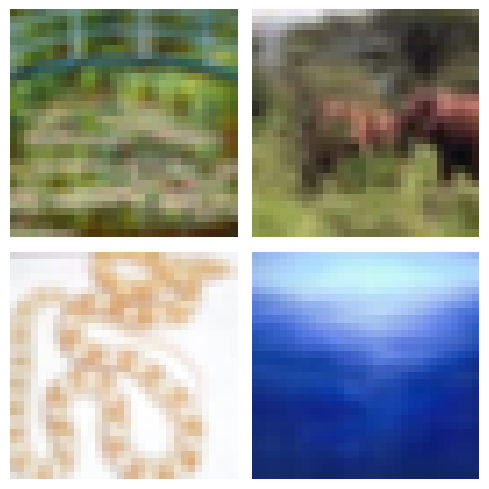

In [ ]:
from train import init_train, train, sample_batch
from graph import graph, visualize_batch
from task.model_baseline import model_baseline
import torch
import torch.nn.functional as F

NUM_CLASSES = init_train()   # CIFAR-100 @ 32px, GPU-cached; returns the class count (100)
total_metrics = []           # each train(...) result gets appended here
x, y = sample_batch(4)           # x: [-1, 1] [4, 3, 32, 32],  y: int [4]
visualize_batch(x)               # the originals

## 1. Mixup
Blend images and labels with a shuffled copy of the batch, `a ~ Beta(alpha, alpha)`.

In [14]:
def mixup(x, y, num_classes, alpha=0.2):
    raise NotImplementedError


xa, ya = mixup(x, y, NUM_CLASSES);        visualize_batch(xa)

NotImplementedError: 

## 2. CutMix
Paste a random box of `x[perm]` into `x` at the same spot, and mix labels by the box area (`1 - a = box_area / (H*W)`).

In [ ]:
def cutmix(x, y, num_classes, alpha=1.0):
    raise NotImplementedError
xa, ya = cutmix(x, y, NUM_CLASSES);       visualize_batch(xa)

TypeError: exceptions must derive from BaseException

## 3. Random erase
With some probability per image, blank a random rectangle and fill it with random values. Labels are unchanged.

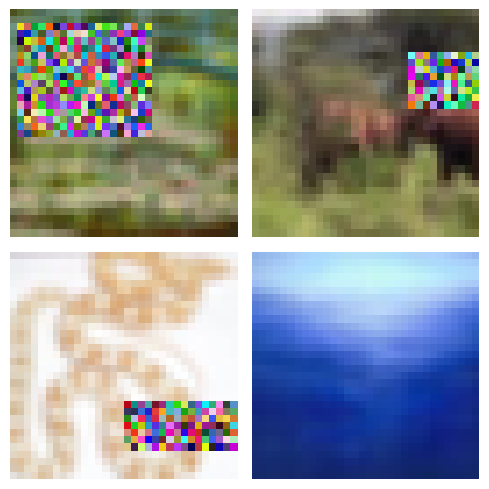

In [ ]:
import math
def random_erase(x, y, num_classes=None, p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3)):
    raise NotImplementedError
xa, ya = random_erase(x, y, NUM_CLASSES); visualize_batch(xa)

In [5]:
import random
def compose(x, y, num_classes, p=[0.3, 0.6, 0.9]):
    r = random.random()
    if r < p[0]:
        return mixup(x, y, NUM_CLASSES)
    elif r > p[0] and r < p[1]:
        return random_erase(x, y, NUM_CLASSES)
    elif r > p[1] and r < p[2]:
        return cutmix(x, y, NUM_CLASSES)
    return x, y

## Train with an augmentation
Train a reference (no aug) once, then the same model with your `process_batch`, and overlay them with `graph`. `train()` re-seeds the data order, so the only difference is the augmentation.

epoch 0:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  0 | train_loss 3.705 | train_acc 13.69 | val_top1 13.93 | val_top5 38.58 | train  5.6s | val  0.7s


epoch 1:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  1 | train_loss 2.751 | train_acc 29.84 | val_top1 20.17 | val_top5 50.24 | train  2.5s | val  0.1s


epoch 2:   0%|          | 0/195 [00:00<?, ?it/s]

...

epoch  7 | train_loss 0.643 | train_acc 82.05 | val_top1 61.68 | val_top5 87.39 | train  2.2s | val  0.1s


epoch 8:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  8 | train_loss 0.469 | train_acc 88.00 | val_top1 62.14 | val_top5 87.75 | train  2.5s | val  0.1s


epoch 9:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  9 | train_loss 0.390 | train_acc 90.83 | val_top1 62.44 | val_top5 87.59 | train  2.4s | val  0.1s
== [no aug] best val_top1 62.44 | final 62.44 | 11.2M params | train 28s + val 2s = 30s ==


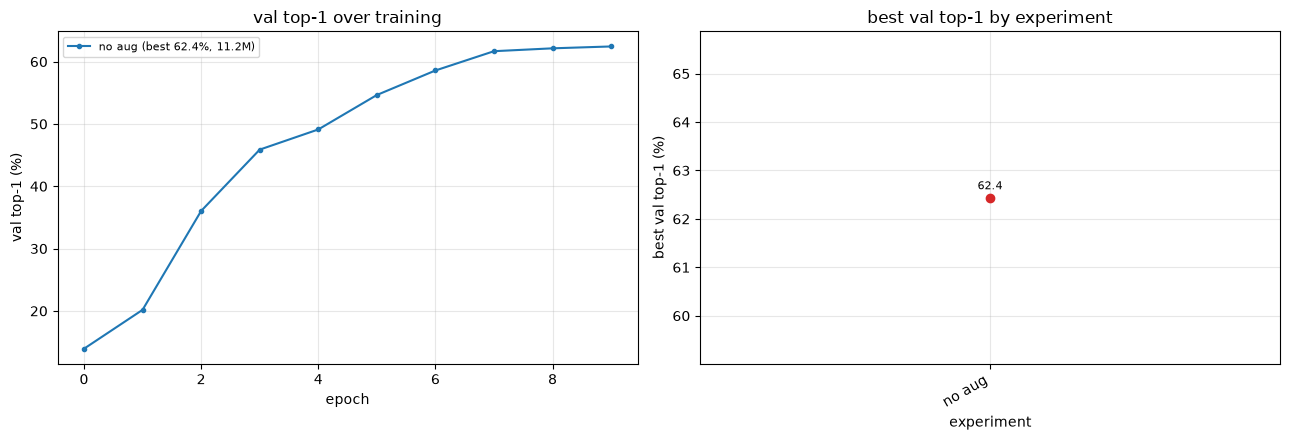

In [6]:
# reference: no augmentation
total_metrics += [train(model_baseline(), "no aug")]
graph(total_metrics)

epoch 0:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  0 | train_loss 3.879 | train_acc 12.69 | val_top1 18.43 | val_top5 46.82 | train  2.1s | val  0.1s


epoch 1:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  1 | train_loss 3.148 | train_acc 27.18 | val_top1 28.23 | val_top5 59.12 | train  2.1s | val  0.1s


epoch 2:   0%|          | 0/195 [00:00<?, ?it/s]

...

epoch  7 | train_loss 1.537 | train_acc 72.37 | val_top1 61.65 | val_top5 87.24 | train  2.2s | val  0.1s


epoch 8:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  8 | train_loss 1.318 | train_acc 78.24 | val_top1 62.64 | val_top5 88.12 | train  2.2s | val  0.1s


epoch 9:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  9 | train_loss 1.325 | train_acc 79.45 | val_top1 63.10 | val_top5 88.12 | train  2.1s | val  0.1s
== [mixup] best val_top1 63.10 | final 63.10 | 11.2M params | train 21s + val 1s = 22s ==


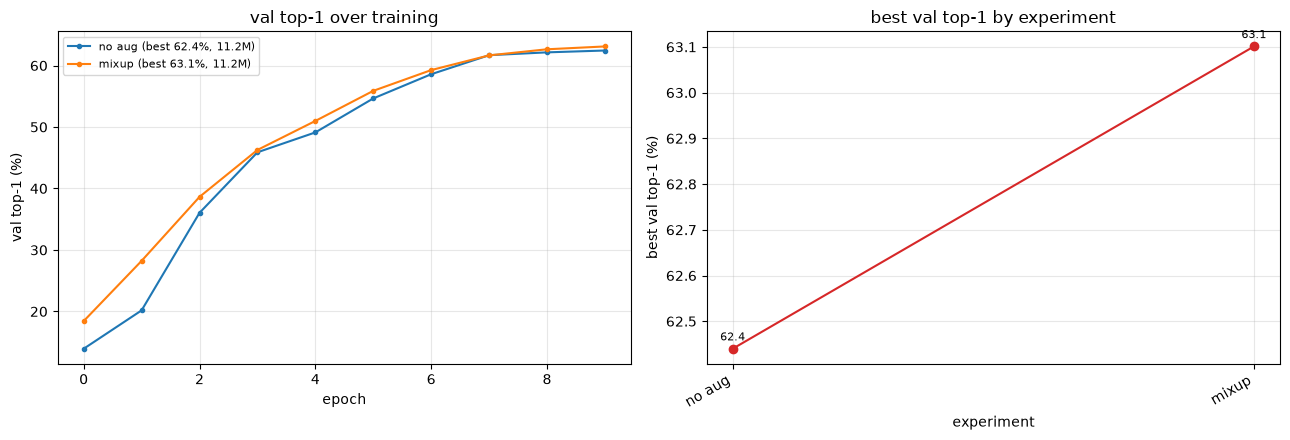

In [7]:
# with your augmentation. process_batch gets (x, y), so wrap to pass NUM_CLASSES:
total_metrics += [train(model_baseline(), "mixup", process_batch=lambda x, y: mixup(x, y, NUM_CLASSES))]
graph(total_metrics)

epoch 0:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  0 | train_loss 3.986 | train_acc 10.89 | val_top1 16.57 | val_top5 41.17 | train  2.7s | val  0.1s


epoch 1:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  1 | train_loss 3.280 | train_acc 23.09 | val_top1 30.22 | val_top5 61.71 | train  2.7s | val  0.1s


epoch 2:   0%|          | 0/195 [00:00<?, ?it/s]

...

epoch  7 | train_loss 1.654 | train_acc 64.59 | val_top1 61.24 | val_top5 87.48 | train  2.4s | val  0.1s


epoch 8:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  8 | train_loss 1.714 | train_acc 64.16 | val_top1 62.36 | val_top5 88.14 | train  2.4s | val  0.1s


epoch 9:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  9 | train_loss 1.579 | train_acc 68.15 | val_top1 63.06 | val_top5 88.51 | train  2.4s | val  0.1s
== [compose] best val_top1 63.06 | final 63.06 | 11.2M params | train 25s + val 1s = 26s ==


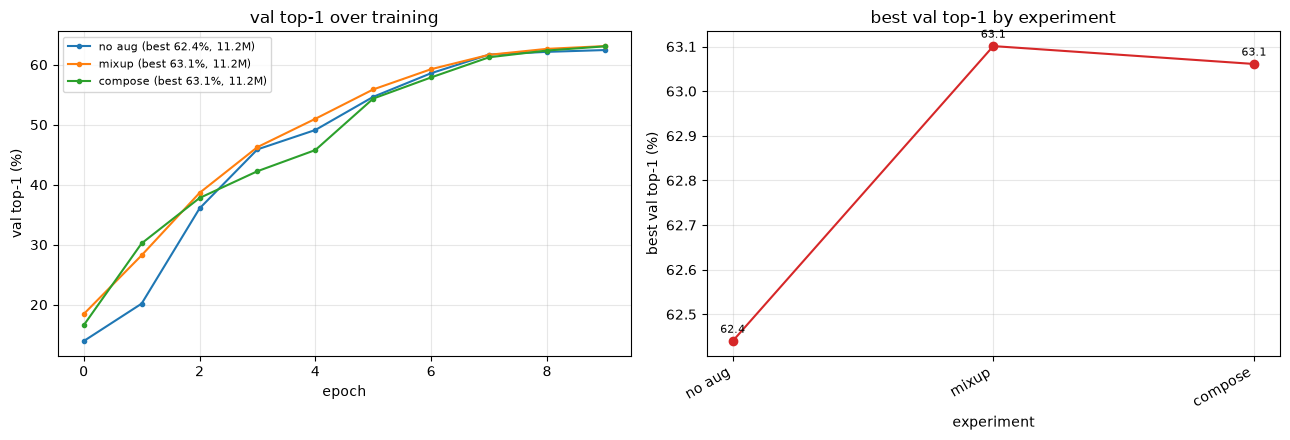

In [8]:
# with your augmentation. process_batch gets (x, y), so wrap to pass NUM_CLASSES:
total_metrics += [train(model_baseline(), "compose", process_batch=lambda x, y: compose(x, y, NUM_CLASSES))]
graph(total_metrics)

epoch 0:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  0 | train_loss 4.031 | train_acc  9.96 | val_top1 11.65 | val_top5 36.24 | train  4.2s | val  0.8s


epoch 1:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  1 | train_loss 3.397 | train_acc 20.96 | val_top1 29.62 | val_top5 60.93 | train  3.7s | val  0.2s


epoch 2:   0%|          | 0/195 [00:00<?, ?it/s]

...

epoch  7 | train_loss 1.797 | train_acc 60.73 | val_top1 59.78 | val_top5 86.10 | train  3.5s | val  0.1s


epoch 8:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  8 | train_loss 1.665 | train_acc 64.82 | val_top1 62.13 | val_top5 87.86 | train  3.4s | val  0.1s


epoch 9:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  9 | train_loss 1.643 | train_acc 66.33 | val_top1 62.82 | val_top5 88.16 | train  3.6s | val  0.1s
== [stage ratio] best val_top1 62.82 | final 62.82 | 15.9M params | train 35s + val 2s = 37s ==


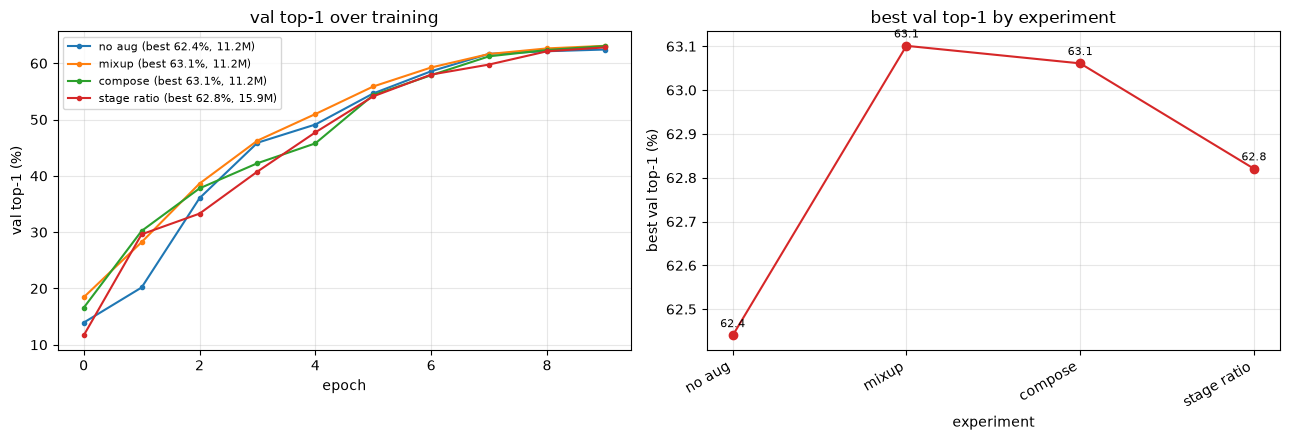

In [ ]:
from task.model_macro import model_macro

model = model_macro(size="resnet18")
name = "stage ratio"
exp_metrics = train(model, name, process_batch=lambda x, y: compose(x, y, NUM_CLASSES))
total_metrics += [exp_metrics]
graph(total_metrics)

epoch 0:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  0 | train_loss 4.040 | train_acc  9.68 | val_top1 16.91 | val_top5 40.74 | train 27.8s | val  1.2s


epoch 1:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  1 | train_loss 3.342 | train_acc 22.63 | val_top1 27.13 | val_top5 57.72 | train 12.3s | val  0.5s


epoch 2:   0%|          | 0/195 [00:00<?, ?it/s]

...

epoch  7 | train_loss 1.714 | train_acc 65.34 | val_top1 61.23 | val_top5 87.14 | train 12.2s | val  0.5s


epoch 8:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  8 | train_loss 1.496 | train_acc 71.01 | val_top1 63.15 | val_top5 87.72 | train 12.2s | val  0.5s


epoch 9:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  9 | train_loss 1.455 | train_acc 72.87 | val_top1 63.72 | val_top5 88.06 | train 12.2s | val  0.5s
== [inverted bottleneck] best val_top1 63.72 | final 63.72 | 16.4M params | train 138s + val 6s = 144s ==


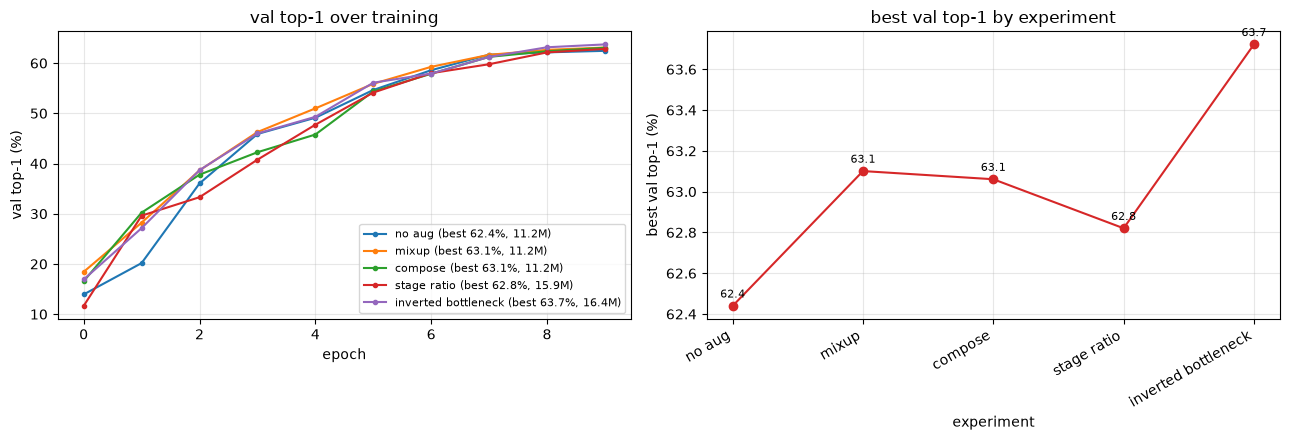

In [ ]:
from task.model_inverted import model_inverted

model = model_inverted(size="resnet18")
name = "inverted bottleneck"
exp_metrics = train(model, name, process_batch=lambda x, y: compose(x, y, NUM_CLASSES))
total_metrics += [exp_metrics]
graph(total_metrics)

epoch 0:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  0 | train_loss 4.318 | train_acc  4.64 | val_top1 10.39 | val_top5 30.36 | train 13.3s | val  0.9s


epoch 1:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  1 | train_loss 3.722 | train_acc 14.38 | val_top1 22.89 | val_top5 51.13 | train 11.5s | val  0.6s


epoch 2:   0%|          | 0/195 [00:00<?, ?it/s]

...

epoch  7 | train_loss 2.283 | train_acc 47.31 | val_top1 54.33 | val_top5 83.32 | train 11.7s | val  0.7s


epoch 8:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  8 | train_loss 2.149 | train_acc 51.02 | val_top1 56.19 | val_top5 84.27 | train 12.1s | val  0.6s


epoch 9:   0%|          | 0/195 [00:00<?, ?it/s]

epoch  9 | train_loss 2.157 | train_acc 52.07 | val_top1 56.23 | val_top5 84.47 | train 11.8s | val  0.6s
== [micro design] best val_top1 56.23 | final 56.23 | 19.1M params | train 118s + val 7s = 124s ==


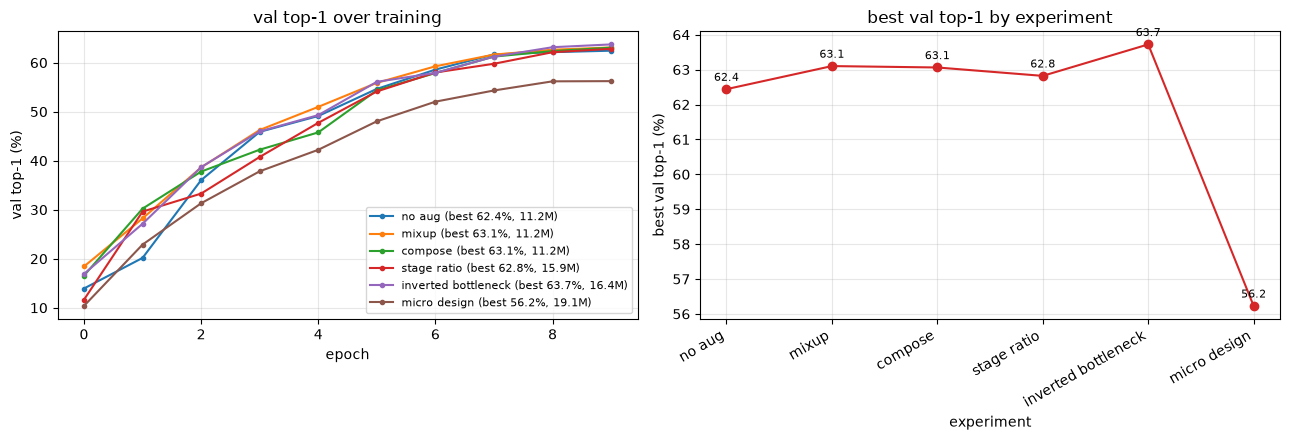

In [ ]:
from task.model_micro import model_micro

model = model_micro(size="resnet18")
name = "micro design"
exp_metrics = train(model, name, process_batch=lambda x, y: compose(x, y, NUM_CLASSES))
total_metrics += [exp_metrics]
graph(total_metrics)

# Testing — SimCLR · CLIP · augmentations
Quick cells to exercise each part. `simclr/` and `clip/` are self-contained folders, run in a fresh process via `run(folder, code)`; the augmentations run inline (they live in `cls/`).

## Augmentations — preview
Preview your mixup / cutmix / random_erase on a [-1, 1] batch.

In [ ]:
# preview your augmentations (implemented in the cells above) on a sample batch
x, y = sample_batch(4)
visualize_batch(x)                              # originals
visualize_batch(mixup(x, y, NUM_CLASSES)[0])
visualize_batch(cutmix(x, y, NUM_CLASSES)[0])
visualize_batch(random_erase(x, y, NUM_CLASSES)[0])

## SimCLR
Contrastive pretraining with a kNN monitor (kNN top-1 should climb above the 1% chance).

In [ ]:
# component check: NT-Xent loss + model shapes
run("simclr/task", '''
import torch
from loss import NTXentLoss
from model import build_model
z1, z2 = torch.randn(8, 128), torch.randn(8, 128)
print("NT-Xent (random):", float(NTXentLoss(0.5)(z1, z2)))
m = build_model()
print("z", tuple(m(torch.zeros(4,3,32,32)).shape), "| h", tuple(m.features(torch.zeros(4,3,32,32)).shape))
''')

In [ ]:
# quick pretrain (5 epochs)
run("simclr/task", "from train import main; main(epochs=5, eval_every=1, num_workers=8)")

## CLIP
Image/class contrastive pretraining with zero-shot eval (zero-shot top-1 rises above 1%). Swap the image encoder with `vision='resnet'` or `vision='vit'`.

In [ ]:
# component check: CLIP loss with REPEATED classes (multi-positive target)
run("clip/task", '''
import torch
from model import build_model
from loss import CLIPLoss
m = build_model(vision="resnet")
x = torch.randn(8,3,32,32); y = torch.tensor([0,0,1,1,2,3,4,5])   # class 0,1 repeated
ie, ce = m(x, y)
print("emb", tuple(ie.shape), "| CLIP loss (dup classes):", float(CLIPLoss()(ie, ce, y, m.logit_scale)))
''')

In [ ]:
# quick pretrain -- ResNet image encoder
run("clip/task", "from train import main; main(vision='resnet', epochs=5, eval_every=1)")

In [ ]:
# quick pretrain -- ViT image encoder
run("clip/task", "from train import main; main(vision='vit', epochs=5, eval_every=1)")

In [ ]:
# optional: unique-class batches (batch 64) -> the loss reduces to the diagonal target
run("clip/task", "from train import main; main(vision='resnet', one_per_class=True, batch_size=64, epochs=5, eval_every=1)")